In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snb

In [3]:
df=pd.read_excel("superstore_sales.xlsx",sheet_name='Orders')

In [4]:
print("Shape:",df.shape)
print(df.columns.tolist())
print(df.info())
print(df.describe())

Shape: (51290, 26)
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'month', 'Month number', 'Profit Margin %', 'Delivery Days', 'Sales Contribution %']
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              51290 non-null  str           
 1   order_date            51290 non-null  datetime64[us]
 2   ship_date             51290 non-null  datetime64[us]
 3   ship_mode             51290 non-null  str           
 4   customer_name         51290 non-null  str           
 5   segment               51290 non-null  str           
 6   state                 51290 non-null  str           
 7   countr

In [5]:
print("Total Sales:",round(df['sales'].sum(),2))
print("Total profit:",round(df['profit'].sum(),2))
print("Average Discount:",round(df['discount'].mean()*100,1),"%")
print("Total orders:",len(df))
print("Markets:",df['market'].unique())
print("Categories:",df['category'].unique())


Total Sales: 12642501.91
Total profit: 1469034.82
Average Discount: 14.3 %
Total orders: 51290
Markets: <StringArray>
['Africa', 'APAC', 'EMEA', 'EU', 'Canada', 'LATAM', 'US']
Length: 7, dtype: str
Categories: <StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str


In [6]:
tables=df[df['sub_category']=='Tables']

print("tables Analysis")
print("Total Sales:",round(tables['sales'].sum(),2))
print("Total profit:",round(tables['profit'].sum(),2))
print("Average discount:",round(tables['discount'].mean()*100,1),"%")
print("Average shipping cost:",round(tables['shipping_cost'].mean()*100,1))
print("Total Orders:",len(tables))
print("Average profit margin:",round(tables['Profit Margin %'].mean()*100,1),"%")
      



tables Analysis
Total Sales: 757041.92
Total profit: -64083.39
Average discount: 29.1 %
Average shipping cost: 9275.4
Total Orders: 861
Average profit margin: -2420.5 %


In [7]:
# Tables vs rest of sub-categories
subcat = df.groupby('sub_category').agg(
    total_sales   = ('sales', 'sum'),
    total_profit  = ('profit', 'sum'),
    avg_discount  = ('discount', 'mean'),
    avg_shipping  = ('shipping_cost', 'mean')
).round(2)

subcat['margin_pct'] = (subcat['total_profit'] / 
                         subcat['total_sales'] * 100).round(1)

subcat = subcat.sort_values('total_profit', ascending=False)
print(subcat)


              total_sales  total_profit  avg_discount  avg_shipping  \
sub_category                                                          
Copiers        1509436.27     258567.55          0.12         71.75   
Phones         1706824.14     216717.01          0.15         55.08   
Bookcases      1466572.24     161924.42          0.15         64.49   
Chairs         1501681.76     141973.80          0.16         47.82   
Appliances     1011064.30     141680.59          0.14         61.71   
Accessories     749237.02     129626.31          0.12         27.16   
Storage        1127085.86     108461.49          0.14         23.83   
Binders         461911.51      72449.85          0.18          7.83   
Paper           244291.72      59207.68          0.11          7.54   
Machines        779060.07      58867.87          0.17         53.25   
Art             372091.97      57953.91          0.12          8.46   
Furnishings     385578.26      46967.43          0.15         12.85   
Envelo

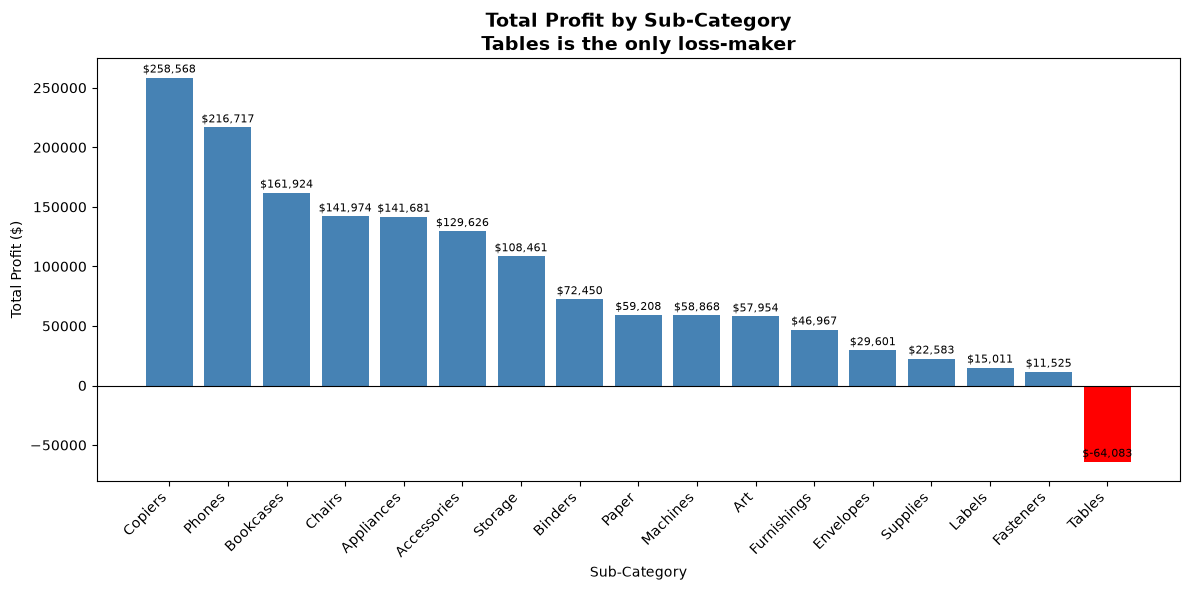


Recommendation: Cap Tables discount at 15%
Estimated profit improvement: ~$45,000


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

# Color bars: red for loss, green for profit
colors = ['red' if x < 0 else 'steelblue' 
          for x in subcat['total_profit']]

bars = ax.bar(subcat.index, subcat['total_profit'], 
              color=colors, edgecolor='none')

# Add a zero line
ax.axhline(y=0, color='black', linewidth=0.8)

# Labels
ax.set_title('Total Profit by Sub-Category\n'
             'Tables is the only loss-maker', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Total Profit ($)')
plt.xticks(rotation=45, ha='right')

# Highlight Tables value
for bar, val in zip(bars, subcat['total_profit']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 2000,
            f'${val:,.0f}', 
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('problem1_tables_crisis.png', dpi=150)
plt.show()

print("\nRecommendation: Cap Tables discount at 15%")
print("Estimated profit improvement: ~$45,000")

In [9]:
tables = df[df['sub_category'] == 'Tables']

# Current situation
current_sales    = tables['sales'].sum()
current_profit   = tables['profit'].sum()
current_discount = tables['discount'].mean()
current_margin   = current_profit / current_sales

print("=== CURRENT SITUATION ===")
print(f"Avg Discount:   {current_discount*100:.1f}%")
print(f"Total Sales:    ${current_sales:,.0f}")
print(f"Total Profit:   ${current_profit:,.0f}")
print(f"Profit Margin:  {current_margin*100:.1f}%")

# If we cap discount at 15%
# Compare with Chairs (16% discount, similar product)
chairs = df[df['sub_category'] == 'Chairs']
chairs_margin = chairs['profit'].sum() / chairs['sales'].sum()

print("\n=== IF DISCOUNT CAPPED AT 15% ===")
print(f"Target margin (based on Chairs): {chairs_margin*100:.1f}%")
estimated_profit = current_sales * chairs_margin
improvement = estimated_profit - current_profit

print(f"Estimated Profit: ${estimated_profit:,.0f}")
print(f"Profit Improvement: ${improvement:,.0f}")

=== CURRENT SITUATION ===
Avg Discount:   29.1%
Total Sales:    $757,042
Total Profit:   $-64,083
Profit Margin:  -8.5%

=== IF DISCOUNT CAPPED AT 15% ===
Target margin (based on Chairs): 9.5%
Estimated Profit: $71,573
Profit Improvement: $135,657


In [10]:
#EMEA underperformance
market = df.groupby('market').agg(
    total_sales  = ('sales', 'sum'),
    total_profit = ('profit', 'sum'),
    avg_discount = ('discount', 'mean'),
    avg_shipping = ('shipping_cost', 'mean')
).round(2)
market['margin_pct'] = (market['total_profit'] / 
                         market['total_sales'] * 100).round(1)

market_sorted = market.sort_values('margin_pct', ascending=False)

print("=== MARKET PERFORMANCE WITH MARGIN ===")
print(market_sorted[['total_sales', 'total_profit', 
                      'avg_discount', 'margin_pct']])


=== MARKET PERFORMANCE WITH MARGIN ===
        total_sales  total_profit  avg_discount  margin_pct
market                                                     
Canada     66928.17      17817.39          0.00        26.6
EU       2938089.06     372829.74          0.10        12.7
US       2297200.86     286397.02          0.16        12.5
APAC     3585744.13     437577.58          0.15        12.2
Africa    783773.21      88871.63          0.16        11.3
LATAM    2164605.17     221643.49          0.14        10.2
EMEA      806161.31      43897.97          0.20         5.4


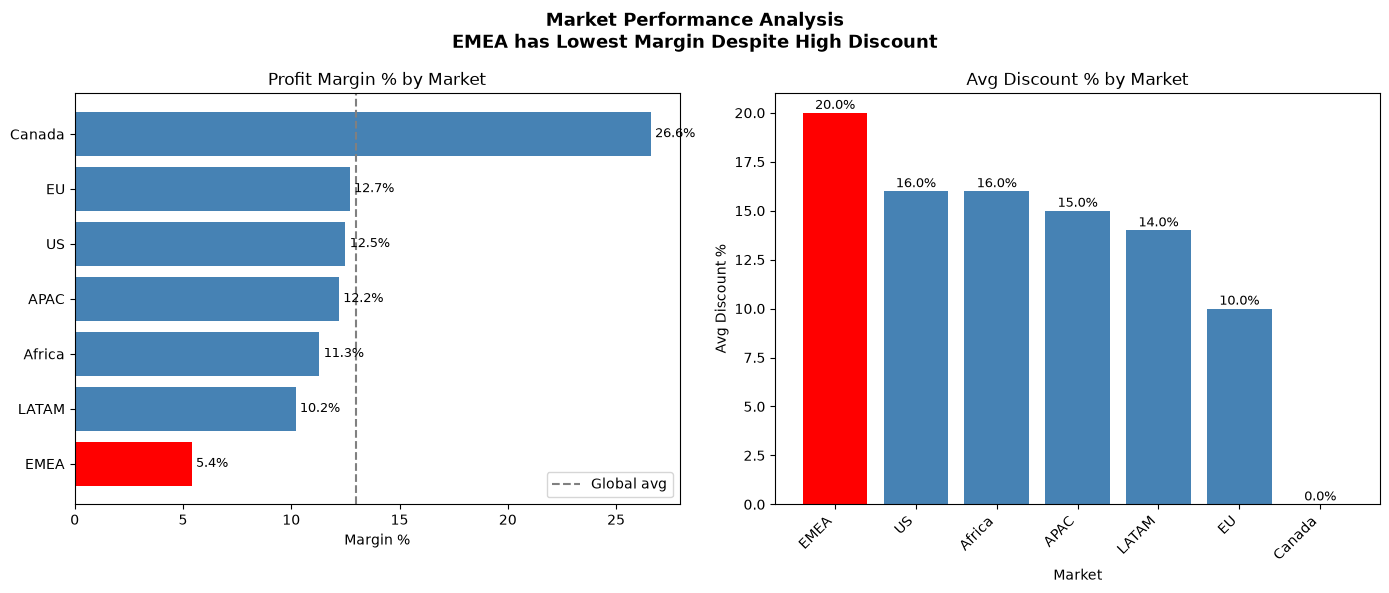

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Market Performance Analysis\nEMEA has Lowest Margin Despite High Discount',
             fontsize=13, fontweight='bold')

# Chart 1 — Margin % by market
market['margin_pct'] = (market['total_profit'] /
                        market['total_sales'] * 100).round(1)
market_sorted = market.sort_values('margin_pct')

colors1 = ['red' if m < 8 else 'steelblue'
           for m in market_sorted['margin_pct']]

bars1 = axes[0].barh(market_sorted.index,
                     market_sorted['margin_pct'],
                     color=colors1, edgecolor='none')
axes[0].axvline(x=market['margin_pct'].mean(),
                color='gray', linestyle='--',
                label='Global avg')
axes[0].set_title('Profit Margin % by Market')
axes[0].set_xlabel('Margin %')
axes[0].legend()

for bar, val in zip(bars1, market_sorted['margin_pct']):
    axes[0].text(val + 0.2, bar.get_y() +
                 bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9)

# Chart 2 — Discount % by market
market_sorted2 = market.sort_values('avg_discount',
                                     ascending=False)
colors2 = ['red' if m == 'EMEA' else 'steelblue'
           for m in market_sorted2.index]

bars2 = axes[1].bar(market_sorted2.index,
                    market_sorted2['avg_discount']*100,
                    color=colors2, edgecolor='none')
axes[1].set_title('Avg Discount % by Market')
axes[1].set_xlabel('Market')
axes[1].set_ylabel('Avg Discount %')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars2,
                    market_sorted2['avg_discount']*100):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.2, f'{val:.1f}%',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('problem2_emea.png', dpi=150)
plt.show()

In [12]:
# Business Problem 3 — Discount Strategy
subcat=df.groupby('sub_category').agg(
    Total_Sales=('sales','sum'),
    Total_profit=('profit','sum'),
    Avg_discount=('discount','mean')).round(2)

subcat['margin_pct']=(subcat['Total_profit']/subcat['Total_Sales']*100).round(1)
subcat['avg_discount_percentage']=(subcat['Avg_discount']*100).round(1)
subcat = subcat.sort_values('avg_discount_percentage', ascending=False)

print("=== DISCOUNT VS MARGIN BY SUB-CATEGORY ===")
print(subcat[['avg_discount_percentage', 'Total_profit', 
              'margin_pct']].to_string())


    

=== DISCOUNT VS MARGIN BY SUB-CATEGORY ===
              avg_discount_percentage  Total_profit  margin_pct
sub_category                                                   
Tables                           29.0     -64083.39        -8.5
Binders                          18.0      72449.85        15.7
Machines                         17.0      58867.87         7.6
Chairs                           16.0     141973.80         9.5
Furnishings                      15.0      46967.43        12.2
Bookcases                        15.0     161924.42        11.0
Phones                           15.0     216717.01        12.7
Storage                          14.0     108461.49         9.6
Appliances                       14.0     141680.59        14.0
Fasteners                        14.0      11525.42        13.8
Envelopes                        13.0      29601.12        17.3
Supplies                         13.0      22583.26         9.3
Accessories                      12.0     129626.31        17

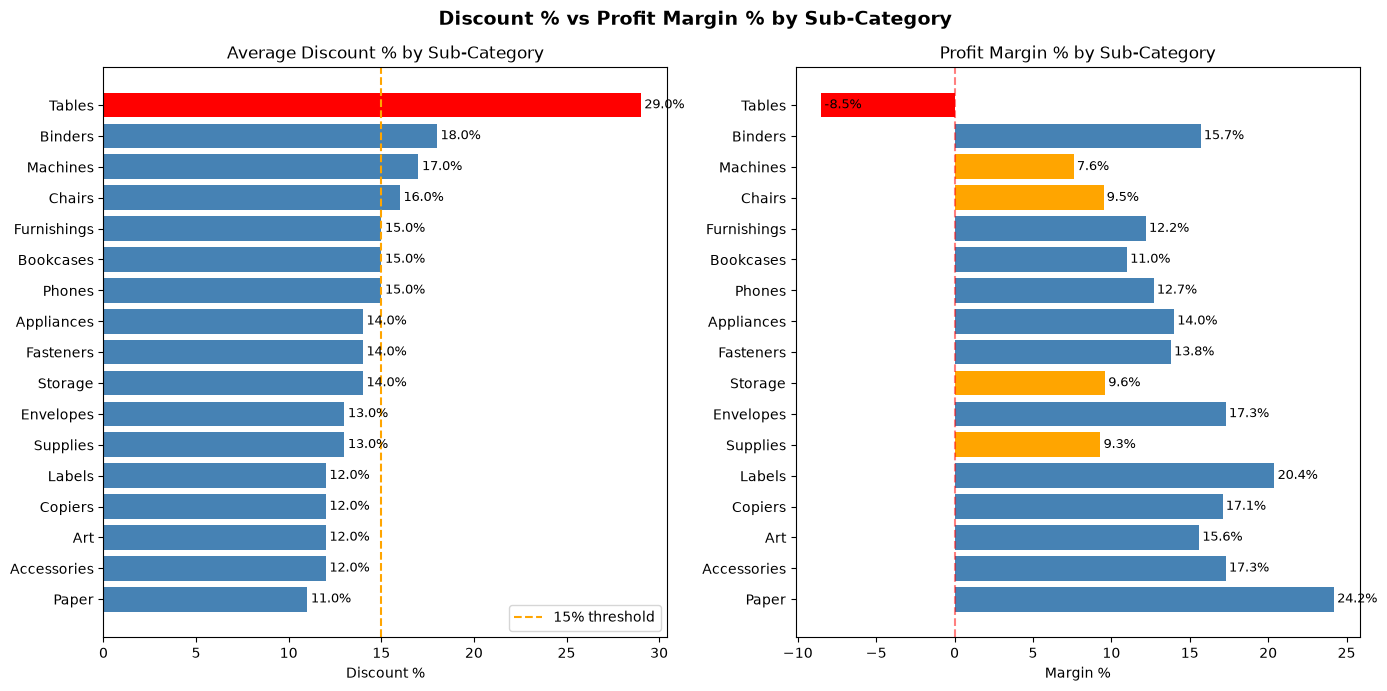

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Discount % vs Profit Margin % by Sub-Category',
             fontsize=14, fontweight='bold')

subcat_sorted = subcat.sort_values('avg_discount_percentage', 
                                    ascending=True)

# Chart 1 — Avg Discount % (horizontal bar)
colors1 = ['red' if x == 'Tables' else 'steelblue' 
           for x in subcat_sorted.index]

axes[0].barh(subcat_sorted.index, 
             subcat_sorted['avg_discount_percentage'],
             color=colors1, edgecolor='none')

axes[0].set_title('Average Discount % by Sub-Category')
axes[0].set_xlabel('Discount %')
axes[0].axvline(x=15, color='orange', 
                linestyle='--', label='15% threshold')
axes[0].legend()

for i, val in enumerate(subcat_sorted['avg_discount_percentage']):
    axes[0].text(val + 0.2, i, f'{val}%', 
                 va='center', fontsize=9)

# Chart 2 — Profit Margin % (horizontal bar)
colors2 = ['red' if x < 0 else 
           'orange' if x < 10 else 
           'steelblue' 
           for x in subcat_sorted['margin_pct']]

axes[1].barh(subcat_sorted.index,
             subcat_sorted['margin_pct'],
             color=colors2, edgecolor='none')

axes[1].set_title('Profit Margin % by Sub-Category')
axes[1].set_xlabel('Margin %')
axes[1].axvline(x=0, color='red',
                linestyle='--', alpha=0.5)

for i, val in enumerate(subcat_sorted['margin_pct']):
    axes[1].text(val + 0.2, i, f'{val}%',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('problem3_discount_strategy.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Business Problem 4 — Shipping Cost Impact
shipping = df.groupby('sub_category').agg(
    total_profit  = ('profit', 'sum'),
    total_sales   = ('sales', 'sum'),
    avg_shipping  = ('shipping_cost', 'mean'),
    avg_discount  = ('discount', 'mean')
).round(2)

shipping['margin_pct'] = (shipping['total_profit'] /
                           shipping['total_sales'] * 100).round(1)
shipping['avg_discount_pct'] = (shipping['avg_discount'] 
                                 * 100).round(1)
shipping = shipping.sort_values('avg_shipping', ascending=False)

print("=== SHIPPING COST vs MARGIN ===")
print(shipping[['avg_shipping', 'avg_discount_pct',
                'total_profit', 'margin_pct']].to_string())

=== SHIPPING COST vs MARGIN ===
              avg_shipping  avg_discount_pct  total_profit  margin_pct
sub_category                                                          
Tables               92.75              29.0     -64083.39        -8.5
Copiers              71.75              12.0     258567.55        17.1
Bookcases            64.49              15.0     161924.42        11.0
Appliances           61.71              14.0     141680.59        14.0
Phones               55.08              15.0     216717.01        12.7
Machines             53.25              17.0      58867.87         7.6
Chairs               47.82              16.0     141973.80         9.5
Accessories          27.16              12.0     129626.31        17.3
Storage              23.83              14.0     108461.49         9.6
Furnishings          12.85              15.0      46967.43        12.2
Supplies             10.23              13.0      22583.26         9.3
Art                   8.46              12.0 

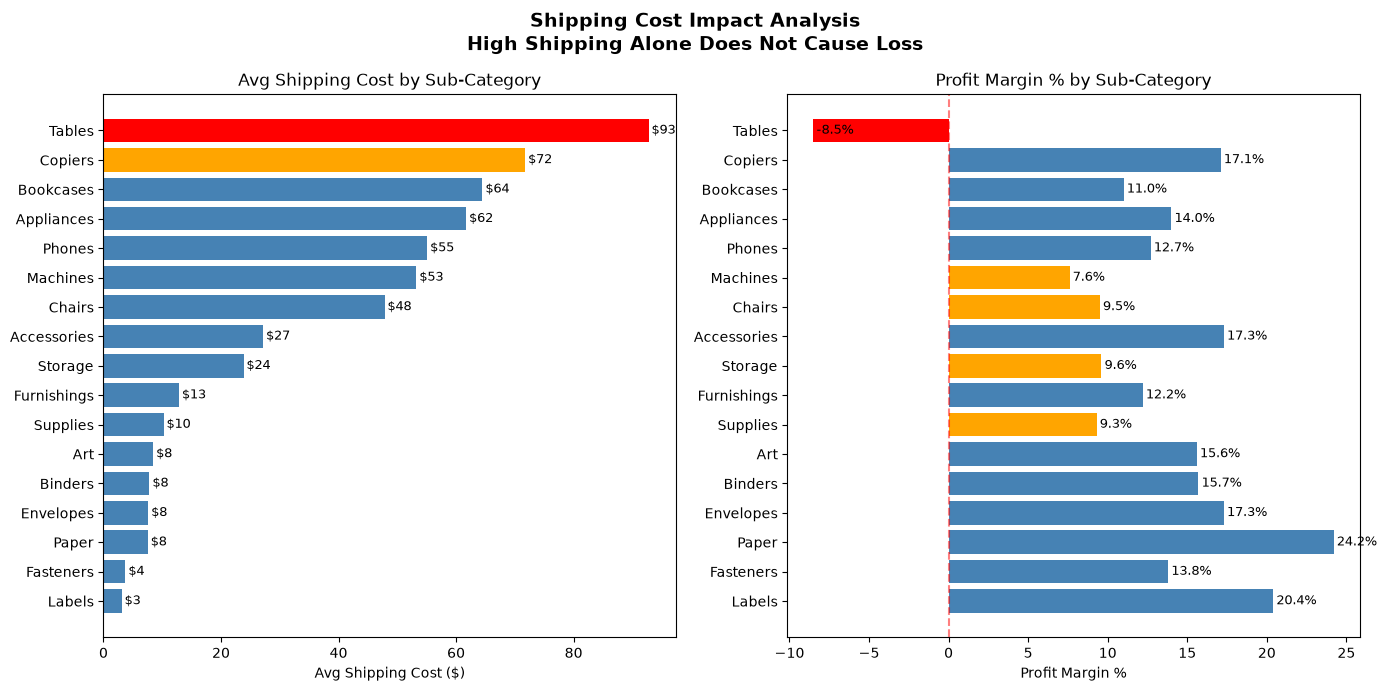


=== KEY FINDING ===
Tables: $92.75 shipping + 29% discount = -8.5% margin
Copiers: $71.75 shipping + 12% discount = 17.1% margin
Conclusion: Discount is the root cause, not shipping!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Shipping Cost Impact Analysis\n'
             'High Shipping Alone Does Not Cause Loss',
             fontsize=14, fontweight='bold')

shipping_sorted = shipping.sort_values('avg_shipping',
                                        ascending=True)

# Chart 1 — Avg Shipping Cost
colors1 = ['red' if x == 'Tables' else
           'orange' if x == 'Copiers' else
           'steelblue'
           for x in shipping_sorted.index]

axes[0].barh(shipping_sorted.index,
             shipping_sorted['avg_shipping'],
             color=colors1, edgecolor='none')
axes[0].set_title('Avg Shipping Cost by Sub-Category')
axes[0].set_xlabel('Avg Shipping Cost ($)')

for i, val in enumerate(shipping_sorted['avg_shipping']):
    axes[0].text(val + 0.5, i, f'${val:.0f}',
                 va='center', fontsize=9)

# Chart 2 — Margin % (same order)
colors2 = ['red' if x < 0 else
           'orange' if x < 10 else
           'steelblue'
           for x in shipping_sorted['margin_pct']]

axes[1].barh(shipping_sorted.index,
             shipping_sorted['margin_pct'],
             color=colors2, edgecolor='none')
axes[1].set_title('Profit Margin % by Sub-Category')
axes[1].set_xlabel('Profit Margin %')
axes[1].axvline(x=0, color='red',
                linestyle='--', alpha=0.5)

for i, val in enumerate(shipping_sorted['margin_pct']):
    axes[1].text(val + 0.2, i, f'{val}%',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('problem4_shipping.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("\n=== KEY FINDING ===")
print("Tables: $92.75 shipping + 29% discount = -8.5% margin")
print("Copiers: $71.75 shipping + 12% discount = 17.1% margin")
print("Conclusion: Discount is the root cause, not shipping!")

In [16]:
# Business Problem 5 — Market Growth Opportunity
growth = df.groupby('market').agg(
    total_sales    = ('sales', 'sum'),
    total_profit   = ('profit', 'sum'),
    total_orders   = ('sales', 'count'),
    avg_discount   = ('discount', 'mean')
).round(2)

growth['margin_pct'] = (growth['total_profit'] /
                         growth['total_sales'] * 100).round(1)

growth['avg_order_value'] = (growth['total_sales'] /
                              growth['total_orders']).round(2)

growth = growth.sort_values('total_sales', ascending=False)

print("=== MARKET GROWTH OPPORTUNITY ===")
print(growth[['total_sales', 'total_profit',
              'margin_pct', 'avg_order_value',
              'total_orders']].to_string())


=== MARKET GROWTH OPPORTUNITY ===
        total_sales  total_profit  margin_pct  avg_order_value  total_orders
market                                                                      
APAC     3585744.13     437577.58        12.2           325.92         11002
EU       2938089.06     372829.74        12.7           293.81         10000
US       2297200.86     286397.02        12.5           229.86          9994
LATAM    2164605.17     221643.49        10.2           210.28         10294
EMEA      806161.31      43897.97         5.4           160.30          5029
Africa    783773.21      88871.63        11.3           170.87          4587
Canada     66928.17      17817.39        26.6           174.29           384


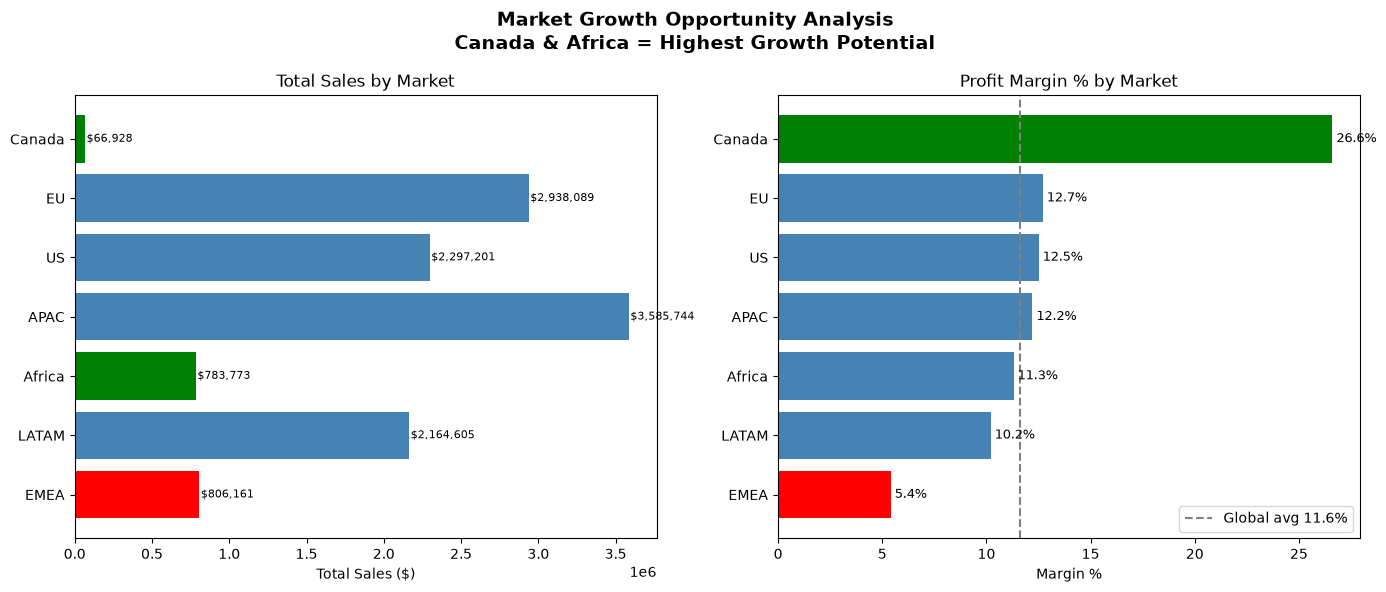


=== RECOMMENDATIONS ===
1. EXPAND: Canada (26.6% margin) & Africa (11.3%)
2. PROTECT: APAC & EU (healthy margins, high sales)
3. FIX FIRST: EMEA (reduce discount from 20% to 10%)
4. MONITOR: LATAM (decent sales but margin slipping)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Market Growth Opportunity Analysis\n'
             'Canada & Africa = Highest Growth Potential',
             fontsize=14, fontweight='bold')

growth_sorted = growth.sort_values('margin_pct',
                                    ascending=True)

# Chart 1 — Total Sales by Market
colors1 = ['green'  if x in ['Canada', 'Africa'] else
           'red'    if x == 'EMEA' else
           'steelblue'
           for x in growth_sorted.index]

axes[0].barh(growth_sorted.index,
             growth_sorted['total_sales'],
             color=colors1, edgecolor='none')
axes[0].set_title('Total Sales by Market')
axes[0].set_xlabel('Total Sales ($)')

for i, val in enumerate(growth_sorted['total_sales']):
    axes[0].text(val + 10000, i, f'${val:,.0f}',
                 va='center', fontsize=8)

# Chart 2 — Margin % by Market
colors2 = ['green'  if x > 20 else
           'red'    if x < 8  else
           'steelblue'
           for x in growth_sorted['margin_pct']]

axes[1].barh(growth_sorted.index,
             growth_sorted['margin_pct'],
             color=colors2, edgecolor='none')
axes[1].set_title('Profit Margin % by Market')
axes[1].set_xlabel('Margin %')

# Global average line
global_avg = (df['profit'].sum() /
              df['sales'].sum() * 100)
axes[1].axvline(x=global_avg, color='gray',
                linestyle='--', label=f'Global avg {global_avg:.1f}%')
axes[1].legend()

for i, val in enumerate(growth_sorted['margin_pct']):
    axes[1].text(val + 0.2, i, f'{val}%',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('problem5_market_growth.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("\n=== RECOMMENDATIONS ===")
print("1. EXPAND: Canada (26.6% margin) & Africa (11.3%)")
print("2. PROTECT: APAC & EU (healthy margins, high sales)")
print("3. FIX FIRST: EMEA (reduce discount from 20% to 10%)")
print("4. MONITOR: LATAM (decent sales but margin slipping)")

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

subcat = df.groupby('sub_category').agg(
    total_sales  = ('sales', 'sum'),
    total_profit = ('profit', 'sum'),
    avg_discount = ('discount', 'mean')
).round(4)

subcat['margin_pct'] = (subcat['total_profit'] /
                         subcat['total_sales'] * 100).round(2)

X = subcat[['avg_discount']].values
y = subcat['margin_pct'].values

model = LinearRegression()
model.fit(X, y)

r2        = r2_score(y, model.predict(X))
coef      = model.coef_[0]
intercept = model.intercept_

print("=== REGRESSION RESULTS ===")
print(f"R² Score:    {r2:.3f}")
print(f"Coefficient: {coef:.2f}")
print(f"Intercept:   {intercept:.2f}")
print(f"\nInterpretation:")
print(f"Each 1% increase in discount → "
      f"{coef/100:.3f}% change in margin")
print(f"At 0% discount  → margin = {intercept:.1f}%")
print(f"At 15% discount → margin = "
      f"{intercept + coef*0.15:.1f}%")
print(f"At 29% discount → margin = "
      f"{intercept + coef*0.29:.1f}%")

=== REGRESSION RESULTS ===
R² Score:    0.772
Coefficient: -147.43
Intercept:   34.72

Interpretation:
Each 1% increase in discount → -1.474% change in margin
At 0% discount  → margin = 34.7%
At 15% discount → margin = 12.6%
At 29% discount → margin = -8.0%


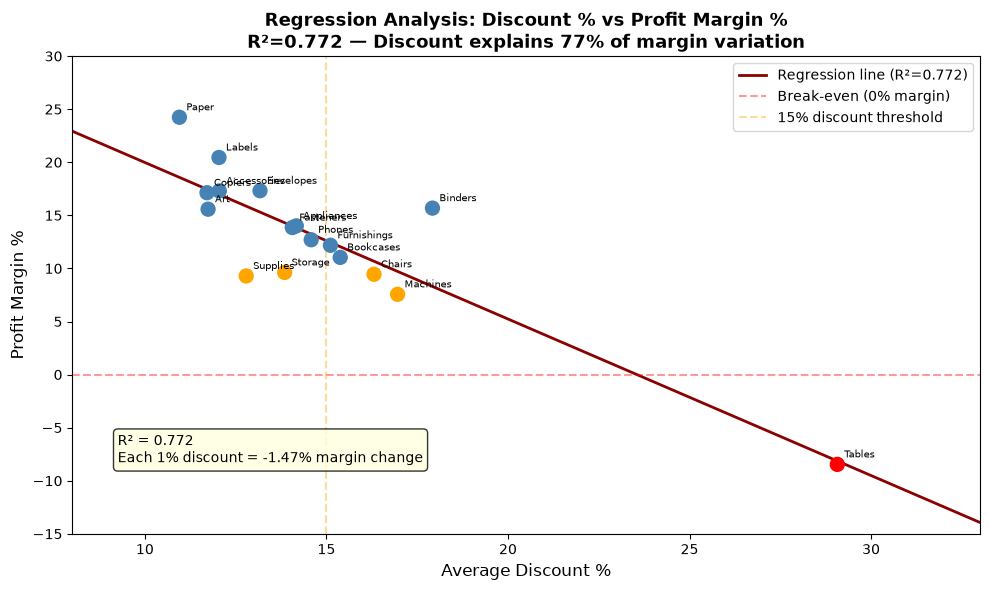

In [19]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data points
colors = ['red' if p < 0 else
          'orange' if p < 10 else
          'steelblue'
          for p in subcat['margin_pct']]

ax.scatter(
    subcat['avg_discount'] * 100,
    subcat['margin_pct'],
    c=colors, s=100, zorder=3
)

# Label each point
for idx, row in subcat.iterrows():
    ax.annotate(
        idx,
        (row['avg_discount']*100, row['margin_pct']),
        fontsize=7,
        xytext=(5, 5),
        textcoords='offset points'
    )

# Draw regression line
x_line = np.linspace(0, 35, 100)
y_line = intercept + coef * (x_line/100)
ax.plot(x_line, y_line,
        color='darkred',
        linewidth=2,
        label=f'Regression line (R²={r2:.3f})')

# Reference lines
ax.axhline(y=0, color='red',
           linestyle='--', alpha=0.4,
           label='Break-even (0% margin)')
ax.axvline(x=15, color='orange',
           linestyle='--', alpha=0.4,
           label='15% discount threshold')

# Titles
ax.set_title('Regression Analysis: Discount % vs Profit Margin %\n'
             'R²=0.772 — Discount explains 77% of margin variation',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Discount %', fontsize=12)
ax.set_ylabel('Profit Margin %', fontsize=12)
ax.legend(loc='upper right')

# Padding
ax.set_xlim(8, 33)
ax.set_ylim(-15, 30)

# Add R² annotation
ax.text(0.05, 0.15,
        f'R² = {r2:.3f}\n'
        f'Each 1% discount = {coef/100:.2f}% margin change',
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle='round',
                  facecolor='lightyellow',
                  alpha=0.8))

plt.tight_layout()
plt.savefig('regression_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

Dashboard saved as superstore_dashboard.html
Open this file in your browser!


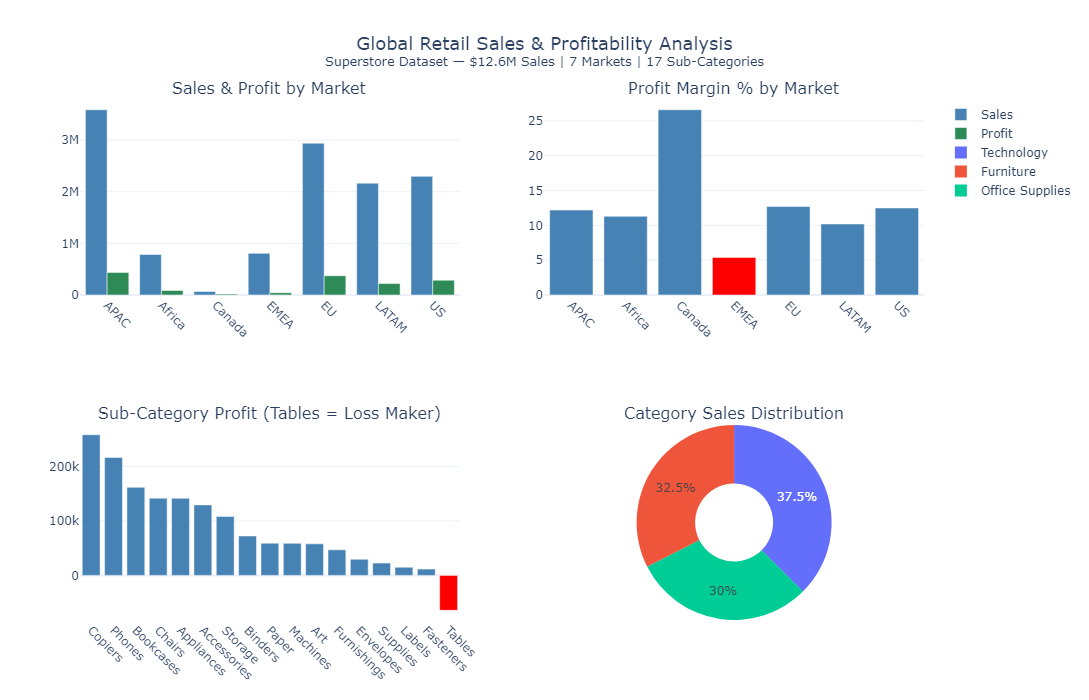

In [20]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Prepare data
market = df.groupby('market').agg(
    total_sales  = ('sales', 'sum'),
    total_profit = ('profit', 'sum'),
    avg_discount = ('discount', 'mean')
).round(2).reset_index()

market['margin_pct'] = (market['total_profit'] /
                         market['total_sales'] * 100).round(1)

subcat = df.groupby('sub_category').agg(
    total_sales  = ('sales', 'sum'),
    total_profit = ('profit', 'sum'),
    avg_discount = ('discount', 'mean')
).round(2).reset_index()

subcat['margin_pct'] = (subcat['total_profit'] /
                         subcat['total_sales'] * 100).round(1)
subcat['avg_discount_pct'] = (subcat['avg_discount']*100).round(1)
subcat = subcat.sort_values('total_profit', ascending=False)

category = df.groupby('category').agg(
    total_sales  = ('sales', 'sum'),
    total_profit = ('profit', 'sum')
).round(2).reset_index()

# Create dashboard with 4 charts
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Sales & Profit by Market',
        'Profit Margin % by Market',
        'Sub-Category Profit (Tables = Loss Maker)',
        'Category Sales Distribution'
    ),
    specs=[[{'type':'bar'}, {'type':'bar'}],
           [{'type':'bar'}, {'type':'pie'}]]
)

# Chart 1 — Sales & Profit by Market
fig.add_trace(
    go.Bar(name='Sales',
           x=market['market'],
           y=market['total_sales'],
           marker_color='steelblue'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='Profit',
           x=market['market'],
           y=market['total_profit'],
           marker_color='seagreen'),
    row=1, col=1
)

# Chart 2 — Margin % by Market
colors_market = ['red' if m < 8 else 'steelblue'
                 for m in market['margin_pct']]
fig.add_trace(
    go.Bar(name='Margin %',
           x=market['market'],
           y=market['margin_pct'],
           marker_color=colors_market,
           showlegend=False),
    row=1, col=2
)

# Chart 3 — Sub-category profit
colors_subcat = ['red' if p < 0 else 'steelblue'
                 for p in subcat['total_profit']]
fig.add_trace(
    go.Bar(name='Sub-cat Profit',
           x=subcat['sub_category'],
           y=subcat['total_profit'],
           marker_color=colors_subcat,
           showlegend=False),
    row=2, col=1
)

# Chart 4 — Category pie
fig.add_trace(
    go.Pie(labels=category['category'],
           values=category['total_sales'],
           hole=0.4),
    row=2, col=2
)

# Layout
fig.update_layout(
    title=dict(
        text='Global Retail Sales & Profitability Analysis<br>'
             '<sup>Superstore Dataset — $12.6M Sales | 7 Markets | 17 Sub-Categories</sup>',
        font=dict(size=18),
        x=0.5
    ),
    height=700,
    barmode='group',
    template='plotly_white',
    showlegend=True
)

fig.update_xaxes(tickangle=45)

# Save
fig.write_html('superstore_dashboard.html')
print("Dashboard saved as superstore_dashboard.html")
print("Open this file in your browser!")
fig.show()